# Separatrix Primitives - 3 Robots and the Jacobian

### Import Relevant Libraries

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg

#### Creating the Vector Field

In [43]:
class VectorField:
    """Class for creating and evaluating vector fields with critical points."""
    
    def __init__(self, field_type='two_vortices'):
        self.field_type = field_type
        
    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        if self.field_type == 'two_vortices':
            # Two co-rotating vortices with a separatrix
            # Left vortex (counterclockwise)
            x1, y1 = -1, 0
            vx1 = -(y - y1)
            vy1 = (x - x1)
            
            # Right vortex (clockwise)
            x2, y2 = 1, 0
            vx2 = (y - y2)
            vy2 = -(x - x2)

            # Combine vector fields with distance-based weighting
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([vx, vy])
        elif self.field_type == 'saddle':
            # Simple saddle point at origin
            return np.array([x, -y])
        else:
            # Default: simple saddle point
            return np.array([x, -y])

### Creating the Robot Cluster


The primitive (update mechanism) is part of the cluster itself

In [44]:
class RobotCluster:
    """Class for managing a cluster of robots for vector field navigation."""
    
    def __init__(self, num_robots=3, formation_radius=0.1):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        # Initialize robots in an equilateral triangle formation
        angles = np.linspace(0, 2*np.pi, num_robots, endpoint=False)
        self.positions = np.zeros((num_robots, 2))
        
        # Set initial centroid
        self.centroid = np.array([-0.13, 1.2])                                                                       # Centroid starts here
        
        # Position robots around the centroid
        for i in range(num_robots):
            self.positions[i] = self.centroid + formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        # Store vector field readings at robot positions
        self.vector_readings = np.zeros((num_robots, 2))
        
    def update_readings(self, vector_field):
        """Update the vector field readings at each robot's position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """
        Compute the Jacobian matrix of the vector field using the robot positions and readings.
        Uses Approach 1 from the document: solving for the critical point directly.
        """
        # Get positions and readings
        x1, y1 = self.positions[0]
        x2, y2 = self.positions[1]
        x3, y3 = self.positions[2]
        u1, v1 = self.vector_readings[0]
        u2, v2 = self.vector_readings[1]
        u3, v3 = self.vector_readings[2]
        
        # Set up the system of equations for u component (ax + by + c = u)
        A_u = np.array([
            [x1, y1, 1],
            [x2, y2, 1],
            [x3, y3, 1]
        ])
        b_u = np.array([u1, u2, u3])
        
        # Set up the system of equations for v component (dx + ey + f = v)
        A_v = A_u.copy()  # Same matrix for both systems
        b_v = np.array([v1, v2, v3])
        
        # Solve the systems
        try:
            a, b, c = np.linalg.solve(A_u, b_u)
            d, e, f = np.linalg.solve(A_v, b_v)
            
            # The Jacobian matrix
            J = np.array([
                [a, b],
                [d, e]
            ])
            
            # Compute the estimated critical point
            critical_matrix = np.array([
                [a, b],
                [d, e]
            ])
            critical_vector = np.array([-c, -f])
            
            try:
                critical_point = np.linalg.solve(critical_matrix, critical_vector)
                return J, critical_point
            except np.linalg.LinAlgError:
                # If the matrix is singular, return the Jacobian but no critical point
                return J, None
            
        except np.linalg.LinAlgError:
            # If the system can't be solved (e.g., collinear robots), return None
            return None, None
    
        
        # Fallback if no clear separatrix detected
        return None, None
    
    def update_positions(self, delta):
        """Update the positions of all robots based on a delta movement of the centroid."""
        old_centroid = self.centroid.copy()
        self.centroid += delta
        
        # Maintain the formation shape around the new centroid
        formation_vectors = self.positions - np.tile(old_centroid, (self.num_robots, 1))  # Use old_centroid
        self.positions = np.tile(self.centroid, (self.num_robots, 1)) + formation_vectors

### Visualization

In [45]:
def visualize_results(centroid_history, critical_points_history, eigenvector_history, robots, plot_field=True):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Set limits
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2, 8)
    
    # Plot the vector field
    if plot_field:
        x = np.linspace(-5, 5, 20)
        y = np.linspace(-2, 8, 20)
        X, Y = np.meshgrid(x, y)
        
        vf = VectorField(field_type='two_vortices')
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(U**2 + V**2)
        U = U / magnitude
        V = V / magnitude
        
        ax.quiver(X, Y, U, V, alpha=0.3, color='gray')
    
    # Plot critical points
    if critical_points_history:
        critical_points = np.array(critical_points_history)
        ax.scatter(critical_points[:, 0], critical_points[:, 1], c='red', marker='x', s=100, label='Estimated Critical Points')
    
    # Plot eigenvectors at certain positions
    for pos, eigvec in eigenvector_history[::10]:  # Plot every 10th eigenvector
        ax.arrow(pos[0], pos[1], eigvec[0]*0.2, eigvec[1]*0.2, head_width=0.05, head_length=0.08, fc='green', ec='green', alpha=0.5)
    
    # Plot robot positions at final step
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'Robot {i+1}')
    
    # Plot centroid path
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Centroid Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    # Labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('3-Robot Cluster Following Separatrix in Vector Field')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    return fig

### Main

Looks like the default behaviour is a special case.

The fall back to the Jacobian case should be main.
The superfallback to average should be the fall back, and explictly called out.
Does that mean I can remove def detect_separatrix_direction(self): altogether?

Using Jacobian Method
[0.92933831 0.02752021]
[[ 0.98733948 -0.0192532 ]
 [ 0.15862142  0.99981464]]
Using Jacobian Method
[0.9286595  0.02710258]
[[ 0.9875056  -0.02054263]
 [ 0.15758394  0.99978898]]
Using Jacobian Method
[0.92791553 0.0266959 ]
[[ 0.9876643  -0.02179876]
 [ 0.15658617  0.99976238]]
Using Jacobian Method
[0.92710862 0.02629974]
[[ 0.98781597 -0.02302274]
 [ 0.15562652  0.99973494]]
Using Jacobian Method
[0.92624093 0.02591368]
[[ 0.98796095 -0.02421568]
 [ 0.15470349  0.99970676]]
Using Jacobian Method
[0.92531456 0.02553731]
[[ 0.98809957 -0.02537861]
 [ 0.15381562  0.99967791]]
Using Jacobian Method
[0.92433153 0.02517026]
[[ 0.98823214 -0.02651256]
 [ 0.15296155  0.99964848]]
Using Jacobian Method
[0.92329384 0.02481217]
[[ 0.98835896 -0.02761849]
 [ 0.15213996  0.99961854]]
Using Jacobian Method
[0.92220338 0.0244627 ]
[[ 0.9884803  -0.02869732]
 [ 0.15134961  0.99958815]]
Using Jacobian Method
[0.92106203 0.02412153]
[[ 0.98859641 -0.02974993]
 [ 0.15058929  0.9

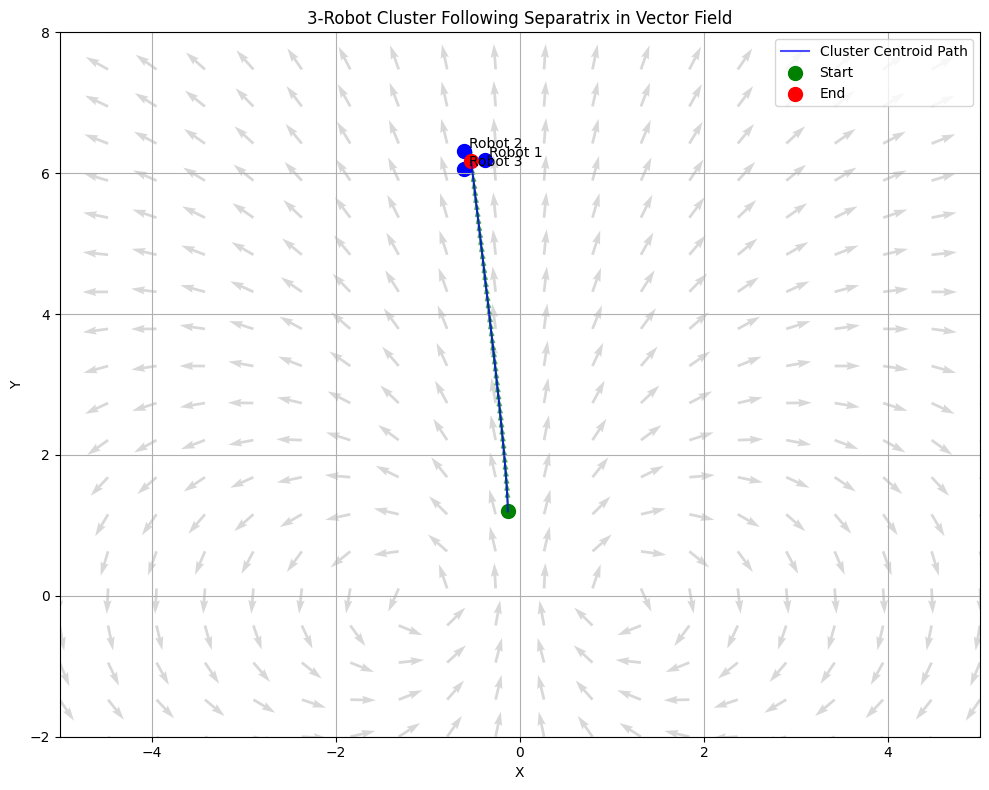

In [46]:

def simulate_separatrix_following():
    
    # Create a vector field
    vector_field = VectorField(field_type='two_vortices')
    
    # Create a robot cluster
    robots = RobotCluster(num_robots=3, formation_radius=0.15)
    
    # Time steps for simulation
    n_steps = 500
    
    # Arrays to store data for plotting
    centroid_history = np.zeros((n_steps, 2))
    critical_points_history = []
    eigenvector_history = []
    
    # Simulation loop
    for step in range(n_steps):

        # Store centroid history
        centroid_history[step] = robots.centroid
        
        # Update vector field readings at robot positions
        robots.update_readings(vector_field)
        
        # Compute Jacobian    
        J, critical_point = robots.compute_jacobian()
        
        if J is not None:
            print('Using Jacobian Method')
            
            # Get eigenvalues and eigenvectors
            eigvals, eigvecs = np.linalg.eig(J)
            print(eigvals)
            print(eigvecs)

            
            # Get average flow at centroid
            actual_flow = np.mean(robots.vector_readings, axis=0)
            actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            
            # Choose eigenvector that best aligns with flow
            eigvec1 = np.real(eigvecs[:, 0])
            eigvec2 = np.real(eigvecs[:, 1])
            eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
            eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
            
            dot1 = abs(np.dot(actual_flow_norm, eigvec1))
            dot2 = abs(np.dot(actual_flow_norm, eigvec2))
            
            if dot1 > dot2:
                primary_eigvec = eigvec1
                secondary_eigvec = eigvec2
                primary_eigval = eigvals[0]
            else:
                primary_eigvec = eigvec2
                secondary_eigvec = eigvec1
                primary_eigval = eigvals[1]
            
            # Ensure direction consistency
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            direction = primary_eigvec
            
            # Store for visualization
            eigenvector_history.append((robots.centroid.copy(), primary_eigvec.copy()))
            
        else:
            # Fallback: use average vector field
            print('Super fall back to using average direction')
            avg_vector = np.mean(robots.vector_readings, axis=0)
            avg_vector_norm = np.linalg.norm(avg_vector)
            if avg_vector_norm > 0:
                direction = avg_vector / avg_vector_norm
            else:
                direction = np.array([0, 1])  # Default upward
        
        # Update position
        step_size = 0.01
        robots.update_positions(step_size * direction)
    
    return centroid_history, critical_points_history, eigenvector_history, robots

if __name__ == "__main__":
    # Run the simulation
    centroid_history, critical_points_history, eigenvector_history, robots = simulate_separatrix_following()
    
    # Visualize the results
    fig = visualize_results(centroid_history, critical_points_history, eigenvector_history, robots)
    plt.show()

Using Jacobian Method
[0.92933831 0.02752021]
[[ 0.98733948 -0.0192532 ]
 [ 0.15862142  0.99981464]]
Using Jacobian Method
[0.9286595  0.02710258]
[[ 0.9875056  -0.02054263]
 [ 0.15758394  0.99978898]]
Using Jacobian Method
[0.92791553 0.0266959 ]
[[ 0.9876643  -0.02179876]
 [ 0.15658617  0.99976238]]
Using Jacobian Method
[0.92710862 0.02629974]
[[ 0.98781597 -0.02302274]
 [ 0.15562652  0.99973494]]
Using Jacobian Method
[0.92624093 0.02591368]
[[ 0.98796095 -0.02421568]
 [ 0.15470349  0.99970676]]
Using Jacobian Method
[0.92531456 0.02553731]
[[ 0.98809957 -0.02537861]
 [ 0.15381562  0.99967791]]
Using Jacobian Method
[0.92433153 0.02517026]
[[ 0.98823214 -0.02651256]
 [ 0.15296155  0.99964848]]
Using Jacobian Method
[0.92329384 0.02481217]
[[ 0.98835896 -0.02761849]
 [ 0.15213996  0.99961854]]
Using Jacobian Method
[0.92220338 0.0244627 ]
[[ 0.9884803  -0.02869732]
 [ 0.15134961  0.99958815]]
Using Jacobian Method
[0.92106203 0.02412153]
[[ 0.98859641 -0.02974993]
 [ 0.15058929  0.9

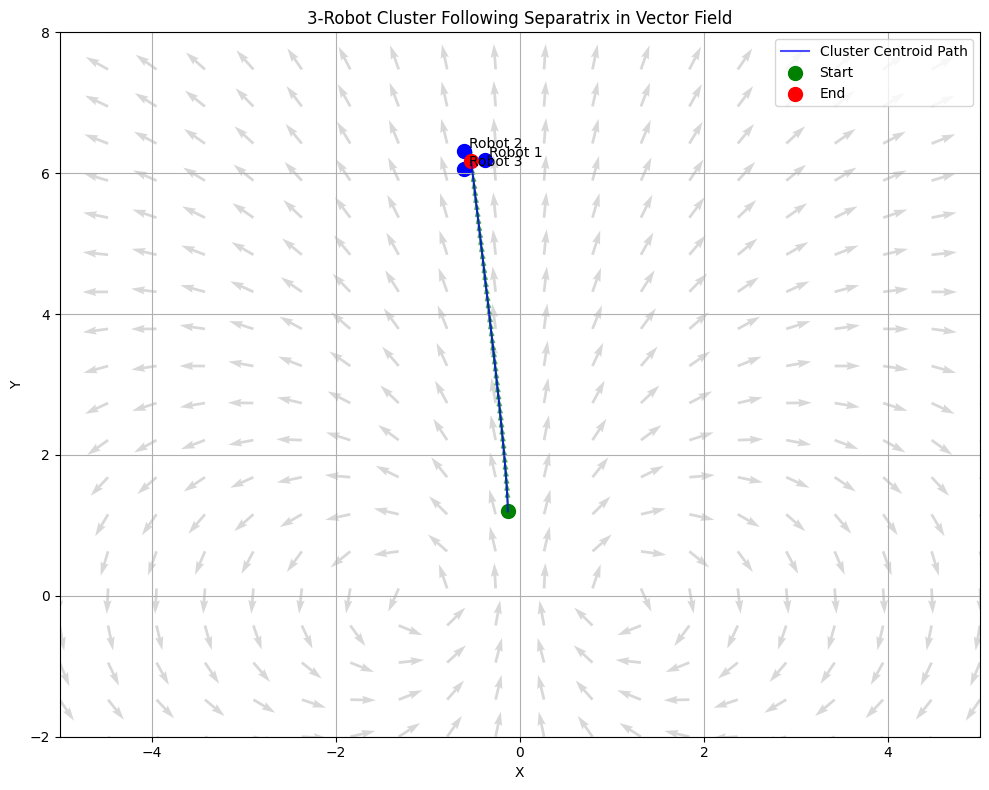

In [47]:
import numpy as np

class RobotClusterEnhanced:
    """Enhanced robot cluster with corrective terms for separatrix following."""
    
    def __init__(self, num_robots=3, formation_radius=0.2):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        # Initialize robots in an equilateral triangle formation
        angles = np.linspace(0, 2*np.pi, num_robots, endpoint=False)
        self.positions = np.zeros((num_robots, 2))
        
        # Set initial centroid
        self.centroid = np.array([-0.03, 1.2])
        
        # Position robots around the centroid
        for i in range(num_robots):
            self.positions[i] = self.centroid + formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        # Store vector field readings at robot positions
        self.vector_readings = np.zeros((num_robots, 2))
        
        # History for adaptive correction
        self.eigenvalue_history = []
        self.eigenvector_history = []
        
    def update_readings(self, vector_field):
        """Update the vector field readings at each robot's position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """Compute the Jacobian matrix using robot positions and readings."""
        # Get positions and readings
        x1, y1 = self.positions[0]
        x2, y2 = self.positions[1]
        x3, y3 = self.positions[2]
        u1, v1 = self.vector_readings[0]
        u2, v2 = self.vector_readings[1]
        u3, v3 = self.vector_readings[2]
        
        # Set up the system of equations
        A = np.array([
            [x1, y1, 1],
            [x2, y2, 1],
            [x3, y3, 1]
        ])
        b_u = np.array([u1, u2, u3])
        b_v = np.array([v1, v2, v3])
        
        try:
            a, b, c = np.linalg.solve(A, b_u)
            d, e, f = np.linalg.solve(A, b_v)
            
            # The Jacobian matrix
            J = np.array([
                [a, b],
                [d, e]
            ])
            
            # Compute critical point estimate
            try:
                critical_point = np.linalg.solve(J, np.array([-c, -f]))
                return J, critical_point
            except np.linalg.LinAlgError:
                return J, None
                
        except np.linalg.LinAlgError:
            return None, None
    
    def compute_corrective_direction(self, J, primary_eigvec, secondary_eigvec, primary_eigval):
        """
        Compute corrective term to maintain separatrix following.
        
        Strategy 1: Eigenvalue monitoring
        - On a true separatrix, eigenvalues should maintain consistent sign pattern
        - If eigenvalue magnitude is decreasing, we might be drifting
        
        Strategy 2: Curvature correction
        - Use the secondary eigenvector to detect and correct drift
        """
        
        # Strategy 1: Eigenvalue-based correction
        eigenvalue_correction = np.zeros(2)
        if len(self.eigenvalue_history) > 5:
            # Check if eigenvalue magnitude is decreasing (indicating drift)
            recent_magnitudes = [abs(ev) for ev in self.eigenvalue_history[-5:]]
            if abs(primary_eigval) < 0.8 * np.mean(recent_magnitudes):
                # We're likely drifting away from the separatrix
                # Correct toward the direction of stronger field gradient
                eigenvalue_correction = 0.0 * secondary_eigvec
        
        # Strategy 2: Divergence-based correction
        # On a separatrix, the divergence perpendicular to it should be zero
        divergence = J[0,0] + J[1,1]  # Trace of Jacobian
        divergence_correction = -0.05 * divergence * secondary_eigvec
        
        # Strategy 3: Variance maximization
        # The separatrix often corresponds to maximum variance direction
        # This is implicitly handled by choosing the appropriate eigenvector
        
        return eigenvalue_correction + divergence_correction
    
    def compute_movement_direction(self, vector_field):
        """Compute the movement direction with corrective terms."""
        
        # Compute Jacobian
        J, critical_point = self.compute_jacobian()
        
        if J is not None:
            # Get eigenvalues and eigenvectors
            eigvals, eigvecs = np.linalg.eig(J)
            
            # Sort by absolute value
            idx = np.argsort(np.abs(eigvals))[::-1]
            eigvals = eigvals[idx]
            eigvecs = eigvecs[:, idx]
            
            # For separatrix following, we typically want:
            # - For unstable separatrix: follow positive eigenvalue direction
            # - For stable separatrix: follow negative eigenvalue direction
            # - For general case: follow largest magnitude eigenvalue
            
            primary_eigvec = np.real(eigvecs[:, 0])
            secondary_eigvec = np.real(eigvecs[:, 1])
            primary_eigval = np.real(eigvals[0])
            secondary_eigval = np.real(eigvals[1])
            
            # Normalize eigenvectors
            primary_eigvec = primary_eigvec / np.linalg.norm(primary_eigvec)
            secondary_eigvec = secondary_eigvec / np.linalg.norm(secondary_eigvec)
            
            # Get actual flow direction
            actual_flow = np.mean(self.vector_readings, axis=0)
            if np.linalg.norm(actual_flow) > 0:
                actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            else:
                actual_flow_norm = primary_eigvec
            
            # Ensure primary eigenvector aligns with flow
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            # Compute corrective term
            correction = self.compute_corrective_direction(J, primary_eigvec, secondary_eigvec, primary_eigval)
            
            # Store history
            self.eigenvalue_history.append(primary_eigval)
            self.eigenvector_history.append(primary_eigvec.copy())
            if len(self.eigenvalue_history) > 20:
                self.eigenvalue_history.pop(0)
                self.eigenvector_history.pop(0)
            
            # Final direction with correction
            direction = primary_eigvec + correction
            direction = direction / np.linalg.norm(direction)
            
            return direction, J, (primary_eigvec, secondary_eigvec), (primary_eigval, secondary_eigval)
            
        else:
            # Fallback: use average vector field
            avg_vector = np.mean(self.vector_readings, axis=0)
            if np.linalg.norm(avg_vector) > 0:
                direction = avg_vector / np.linalg.norm(avg_vector)
            else:
                direction = np.array([0, 1])
            return direction, None, (None, None), (None, None)
    
    def update_positions(self, delta):
        """Update the positions of all robots based on a delta movement of the centroid."""
        old_centroid = self.centroid.copy()
        self.centroid += delta
        
        # Maintain the formation shape around the new centroid
        formation_vectors = self.positions - np.tile(old_centroid, (self.num_robots, 1))
        self.positions = np.tile(self.centroid, (self.num_robots, 1)) + formation_vectors


if __name__ == "__main__":
    # Run the simulation
    centroid_history, critical_points_history, eigenvector_history, robots = simulate_separatrix_following()
    
    # Visualize the results
    fig = visualize_results(centroid_history, critical_points_history, eigenvector_history, robots)
    plt.show()

Using Jacobian Method
[0.92933831 0.02752021]
[[ 0.98733948 -0.0192532 ]
 [ 0.15862142  0.99981464]]
Using Jacobian Method
[0.9286595  0.02710258]
[[ 0.9875056  -0.02054263]
 [ 0.15758394  0.99978898]]
Using Jacobian Method
[0.92791553 0.0266959 ]
[[ 0.9876643  -0.02179876]
 [ 0.15658617  0.99976238]]
Using Jacobian Method
[0.92710862 0.02629974]
[[ 0.98781597 -0.02302274]
 [ 0.15562652  0.99973494]]
Using Jacobian Method
[0.92624093 0.02591368]
[[ 0.98796095 -0.02421568]
 [ 0.15470349  0.99970676]]
Using Jacobian Method
[0.92531456 0.02553731]
[[ 0.98809957 -0.02537861]
 [ 0.15381562  0.99967791]]
Using Jacobian Method
[0.92433153 0.02517026]
[[ 0.98823214 -0.02651256]
 [ 0.15296155  0.99964848]]
Using Jacobian Method
[0.92329384 0.02481217]
[[ 0.98835896 -0.02761849]
 [ 0.15213996  0.99961854]]
Using Jacobian Method
[0.92220338 0.0244627 ]
[[ 0.9884803  -0.02869732]
 [ 0.15134961  0.99958815]]
Using Jacobian Method
[0.92106203 0.02412153]
[[ 0.98859641 -0.02974993]
 [ 0.15058929  0.9

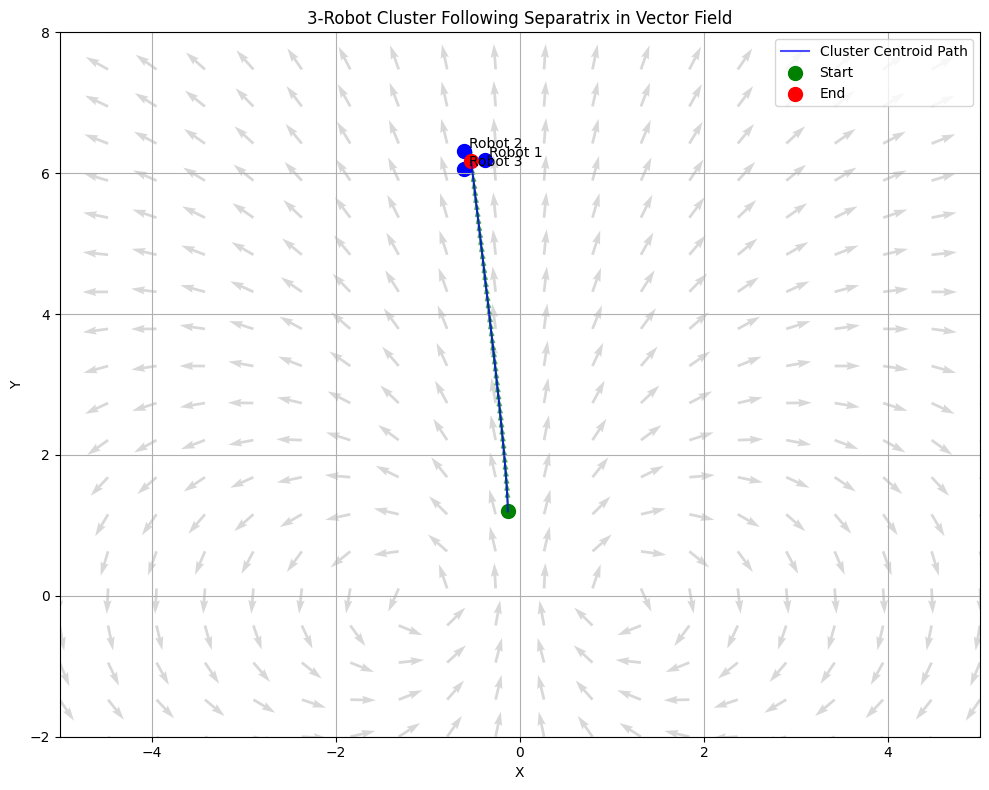

In [49]:
import numpy as np

class RobotClusterEnhanced:
    """Enhanced robot cluster with corrective terms for separatrix following."""
    
    def __init__(self, num_robots=3, formation_radius=0.2):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        # Initialize robots in an equilateral triangle formation
        angles = np.linspace(0, 2*np.pi, num_robots, endpoint=False)
        self.positions = np.zeros((num_robots, 2))
        
        # Set initial centroid
        self.centroid = np.array([-0.03, 1.2])
        
        # Position robots around the centroid
        for i in range(num_robots):
            self.positions[i] = self.centroid + formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        # Store vector field readings at robot positions
        self.vector_readings = np.zeros((num_robots, 2))
        
        # History for adaptive correction
        self.eigenvalue_history = []
        self.eigenvector_history = []
        
    def update_readings(self, vector_field):
        """Update the vector field readings at each robot's position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """Compute the Jacobian matrix using robot positions and readings."""
        # Get positions and readings
        x1, y1 = self.positions[0]
        x2, y2 = self.positions[1]
        x3, y3 = self.positions[2]
        u1, v1 = self.vector_readings[0]
        u2, v2 = self.vector_readings[1]
        u3, v3 = self.vector_readings[2]
        
        # Set up the system of equations
        A = np.array([
            [x1, y1, 1],
            [x2, y2, 1],
            [x3, y3, 1]
        ])
        b_u = np.array([u1, u2, u3])
        b_v = np.array([v1, v2, v3])
        
        try:
            a, b, c = np.linalg.solve(A, b_u)
            d, e, f = np.linalg.solve(A, b_v)
            
            # The Jacobian matrix
            J = np.array([
                [a, b],
                [d, e]
            ])
            
            # Compute critical point estimate
            try:
                critical_point = np.linalg.solve(J, np.array([-c, -f]))
                return J, critical_point
            except np.linalg.LinAlgError:
                return J, None
                
        except np.linalg.LinAlgError:
            return None, None
    
    def compute_corrective_direction(self, J, primary_eigvec, secondary_eigvec, primary_eigval):
        """
        Compute corrective term to maintain separatrix following.
        
        Strategy 1: Eigenvalue monitoring
        - On a true separatrix, eigenvalues should maintain consistent sign pattern
        - If eigenvalue magnitude is decreasing, we might be drifting
        
        Strategy 2: Curvature correction
        - Use the secondary eigenvector to detect and correct drift
        """
        
        # Strategy 1: Eigenvalue-based correction
        eigenvalue_correction = np.zeros(2)
        if len(self.eigenvalue_history) > 5:
            # Check if eigenvalue magnitude is decreasing (indicating drift)
            recent_magnitudes = [abs(ev) for ev in self.eigenvalue_history[-5:]]
            if abs(primary_eigval) < 0.8 * np.mean(recent_magnitudes):
                # We're likely drifting away from the separatrix
                # Correct toward the direction of stronger field gradient
                eigenvalue_correction = 0.1 * secondary_eigvec
        
        # Strategy 2: Divergence-based correction
        # On a separatrix, the divergence perpendicular to it should be zero
        divergence = J[0,0] + J[1,1]  # Trace of Jacobian
        divergence_correction = -0.05 * divergence * secondary_eigvec
        
        # Strategy 3: Variance maximization
        # The separatrix often corresponds to maximum variance direction
        # This is implicitly handled by choosing the appropriate eigenvector
        
        return eigenvalue_correction + divergence_correction
    
    def compute_movement_direction(self, vector_field):
        """Compute the movement direction with corrective terms."""
        
        # Compute Jacobian
        J, critical_point = self.compute_jacobian()
        
        if J is not None:
            # Get eigenvalues and eigenvectors
            eigvals, eigvecs = np.linalg.eig(J)
            
            # Sort by absolute value
            idx = np.argsort(np.abs(eigvals))[::-1]
            eigvals = eigvals[idx]
            eigvecs = eigvecs[:, idx]
            
            # For separatrix following, we typically want:
            # - For unstable separatrix: follow positive eigenvalue direction
            # - For stable separatrix: follow negative eigenvalue direction
            # - For general case: follow largest magnitude eigenvalue
            
            primary_eigvec = np.real(eigvecs[:, 0])
            secondary_eigvec = np.real(eigvecs[:, 1])
            primary_eigval = np.real(eigvals[0])
            secondary_eigval = np.real(eigvals[1])
            
            # Normalize eigenvectors
            primary_eigvec = primary_eigvec / np.linalg.norm(primary_eigvec)
            secondary_eigvec = secondary_eigvec / np.linalg.norm(secondary_eigvec)
            
            # Get actual flow direction
            actual_flow = np.mean(self.vector_readings, axis=0)
            if np.linalg.norm(actual_flow) > 0:
                actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            else:
                actual_flow_norm = primary_eigvec
            
            # Ensure primary eigenvector aligns with flow
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            # Compute corrective term
            correction = self.compute_corrective_direction(J, primary_eigvec, secondary_eigvec, primary_eigval)
            
            # Store history
            self.eigenvalue_history.append(primary_eigval)
            self.eigenvector_history.append(primary_eigvec.copy())
            if len(self.eigenvalue_history) > 20:
                self.eigenvalue_history.pop(0)
                self.eigenvector_history.pop(0)
            
            # Final direction with correction
            direction = primary_eigvec + correction
            direction = direction / np.linalg.norm(direction)
            
            return direction, J, (primary_eigvec, secondary_eigvec), (primary_eigval, secondary_eigval)
            
        else:
            # Fallback: use average vector field
            avg_vector = np.mean(self.vector_readings, axis=0)
            if np.linalg.norm(avg_vector) > 0:
                direction = avg_vector / np.linalg.norm(avg_vector)
            else:
                direction = np.array([0, 1])
            return direction, None, (None, None), (None, None)
    
    def update_positions(self, delta):
        """Update the positions of all robots based on a delta movement of the centroid."""
        old_centroid = self.centroid.copy()
        self.centroid += delta
        
        # Maintain the formation shape around the new centroid
        formation_vectors = self.positions - np.tile(old_centroid, (self.num_robots, 1))
        self.positions = np.tile(self.centroid, (self.num_robots, 1)) + formation_vectors


if __name__ == "__main__":
    # Run the simulation
    centroid_history, critical_points_history, eigenvector_history, robots = simulate_separatrix_following()
    
    # Visualize the results
    fig = visualize_results(centroid_history, critical_points_history, eigenvector_history, robots)
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

class TwoVortexField:
    """Analysis of the two-vortex field from the original code."""
    
    def evaluate(self, x, y):
        """Two co-rotating vortices with a separatrix."""
        # Left vortex (counterclockwise)
        x1, y1 = -1, 0
        vx1 = -(y - y1)
        vy1 = (x - x1)
        
        # Right vortex (clockwise)
        x2, y2 = 1, 0
        vx2 = (y - y2)
        vy2 = -(x - x2)
        
        # Combine vector fields with distance-based weighting
        d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
        d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
        w1 = 1.0 / (d1**2 + 0.1)
        w2 = 1.0 / (d2**2 + 0.1)
        vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
        vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
        return np.array([vx, vy])
    
    def compute_jacobian(self, x, y, h=1e-5):
        """Compute Jacobian matrix using finite differences."""
        J = np.zeros((2, 2))
        
        v0 = self.evaluate(x, y)
        vx_h = self.evaluate(x + h, y)
        vx_mh = self.evaluate(x - h, y)
        vy_h = self.evaluate(x, y + h)
        vy_mh = self.evaluate(x, y - h)
        
        J[0, 0] = (vx_h[0] - vx_mh[0]) / (2 * h)
        J[0, 1] = (vy_h[0] - vy_mh[0]) / (2 * h)
        J[1, 0] = (vx_h[1] - vx_mh[1]) / (2 * h)
        J[1, 1] = (vy_h[1] - vy_mh[1]) / (2 * h)
        
        return J

# Create analysis plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
field = TwoVortexField()

# Common grid
x = np.linspace(-3, 3, 40)
y = np.linspace(-2, 4, 40)
X, Y = np.meshgrid(x, y)

# Plot 1: Vector field
ax = axes[0, 0]
U, V = np.zeros_like(X), np.zeros_like(Y)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        U[i, j], V[i, j] = field.evaluate(X[i, j], Y[i, j])

magnitude = np.sqrt(U**2 + V**2)
ax.streamplot(X, Y, U, V, density=2, color=magnitude, cmap='viridis')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='x=0 separatrix')
ax.plot([-1], [0], 'ro', markersize=10, label='Vortex centers')
ax.plot([1], [0], 'ro', markersize=10)
ax.plot([0.03], [1.2], 'g*', markersize=15, label='Start point')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Two-Vortex Vector Field')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Determinant of Jacobian
ax = axes[0, 1]
Det = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        J = field.compute_jacobian(X[i, j], Y[i, j])
        Det[i, j] = np.linalg.det(J)

contour = ax.contourf(X, Y, Det, levels=np.linspace(-2, 2, 40), cmap='RdBu_r')
zero_contour = ax.contour(X, Y, Det, levels=[0], colors='black', linewidths=3)
plt.colorbar(contour, ax=ax, label='det(J)')
ax.axvline(x=0, color='yellow', linestyle='--', linewidth=2, alpha=0.8)
ax.plot([0.03], [1.2], 'g*', markersize=15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('det(J) with zero contour (black)')

# Plot 3: Gradient of determinant at x=0
ax = axes[0, 2]
y_line = np.linspace(-2, 4, 50)
det_gradient_x = []
det_values = []

for yi in y_line:
    # Compute det(J) gradient at (0, yi)
    h = 0.05
    det_center = np.linalg.det(field.compute_jacobian(0, yi))
    det_right = np.linalg.det(field.compute_jacobian(h, yi))
    det_left = np.linalg.det(field.compute_jacobian(-h, yi))
    
    grad_x = (det_right - det_left) / (2 * h)
    det_gradient_x.append(grad_x)
    det_values.append(det_center)

ax.plot(y_line, det_values, 'b-', linewidth=2, label='det(J) at x=0')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.plot([1.2], [0], 'g*', markersize=15)
ax.set_xlabel('y')
ax.set_ylabel('det(J)')
ax.set_title('Determinant along x=0 separatrix')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Flow along separatrix
ax = axes[1, 0]
# Compute eigenvalues along x=0
y_line = np.linspace(0.5, 3, 30)
eigenvalues = []
for yi in y_line:
    J = field.compute_jacobian(0, yi)
    eigvals, _ = np.linalg.eig(J)
    eigenvalues.append(eigvals)

eigenvalues = np.array(eigenvalues)
ax.plot(y_line, np.real(eigenvalues[:, 0]), 'b-', label='Re(λ₁)')
ax.plot(y_line, np.real(eigenvalues[:, 1]), 'r-', label='Re(λ₂)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.plot([1.2], [0], 'g*', markersize=15)
ax.set_xlabel('y (along x=0)')
ax.set_ylabel('Real part of eigenvalues')
ax.set_title('Eigenvalues along separatrix')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Determinant gradient vectors
ax = axes[1, 1]
# Subsample for clarity
X_sub = X[::4, ::4]
Y_sub = Y[::4, ::4]
grad_X = np.zeros_like(X_sub)
grad_Y = np.zeros_like(Y_sub)

h = 0.05
for i in range(X_sub.shape[0]):
    for j in range(X_sub.shape[1]):
        x, y = X_sub[i, j], Y_sub[i, j]
        
        det_center = np.linalg.det(field.compute_jacobian(x, y))
        det_xp = np.linalg.det(field.compute_jacobian(x + h, y))
        det_xm = np.linalg.det(field.compute_jacobian(x - h, y))
        det_yp = np.linalg.det(field.compute_jacobian(x, y + h))
        det_ym = np.linalg.det(field.compute_jacobian(x, y - h))
        
        grad_X[i, j] = (det_xp - det_xm) / (2 * h)
        grad_Y[i, j] = (det_yp - det_ym) / (2 * h)

# Normalize for visualization
grad_mag = np.sqrt(grad_X**2 + grad_Y**2)
grad_X_norm = -grad_X / (grad_mag + 1e-10)  # Negative to point toward zero
grad_Y_norm = -grad_Y / (grad_mag + 1e-10)

ax.quiver(X_sub, Y_sub, grad_X_norm, grad_Y_norm, grad_mag, 
          scale=30, alpha=0.7, cmap='plasma')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.plot([0.03], [1.2], 'g*', markersize=15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gradient of det(J) pointing toward zero')
ax.grid(True, alpha=0.3)

# Plot 6: Analysis text
ax = axes[1, 2]
ax.text(0.05, 0.95, 'Key Observations:', transform=ax.transAxes, 
        fontsize=12, fontweight='bold', va='top')

observations = [
    '1. The x=0 line is special: it\'s a continuous',
    '   line of degenerate points (not isolated saddles)',
    '',
    '2. det(J) ≈ 0 along the entire x=0 line',
    '',
    '3. The gradient ∇det(J) points horizontally',
    '   toward x=0 when near the separatrix',
    '',
    '4. For this specific field structure, the',
    '   determinant gradient DOES provide useful',
    '   correction information!',
    '',
    '5. This works because the separatrix is a',
    '   "degenerate line" rather than a',
    '   heteroclinic connection between',
    '   isolated saddle points'
]

for i, obs in enumerate(observations):
    ax.text(0.05, 0.85 - i*0.055, obs, transform=ax.transAxes, 
            fontsize=10, va='top')

ax.axis('off')

plt.tight_layout()
plt.show()

# Numerical verification
print("Numerical Analysis at (0.03, 1.2):")
print("-" * 50)
J = field.compute_jacobian(0.03, 1.2)
print(f"Jacobian:\n{J}")
print(f"det(J) = {np.linalg.det(J):.6f}")

eigvals, eigvecs = np.linalg.eig(J)
print(f"\nEigenvalues: {eigvals}")
print(f"Eigenvectors:\n{eigvecs}")

# Check gradient
h = 0.05
det_center = np.linalg.det(field.compute_jacobian(0.03, 1.2))
det_right = np.linalg.det(field.compute_jacobian(0.03 + h, 1.2))
det_left = np.linalg.det(field.compute_jacobian(0.03 - h, 1.2))
grad_x = (det_right - det_left) / (2 * h)

print(f"\nGradient of det(J) in x-direction: {grad_x:.6f}")
print("(Negative value means det(J) decreases toward x=0)")